## Partea 2:Preprocesare

Observam din partea 1 ca dataset ul nu prezinta valori duplicate sau valori lipsa si nu a fost nevoie de transformarea valorilor categorice tip string in valori numerice fiind deja transformate in dataset ul primit.

In schimb am observat ca anumite coloane prezinta un numar mare de outliers astfel ca vom folosii RobusScaler pentru a scala numeric valorile(chiar daca pentru XGBoost nu este neaparat obligatoriu,modelul ocupandu-se deja de astfel de probleme)

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# 1) Citire date brute
df = pd.read_csv('datasets/australian_analysed.dat', sep=' ')

x = df.drop('A15', axis=1)
y = df['A15']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# 4) Scalare pentru coloanele cu % mare de outliers
cols_de_scalat = ['A7', 'A10', 'A14']
scaler = RobustScaler()

x_train[cols_de_scalat] = scaler.fit_transform(x_train[cols_de_scalat])
x_test[cols_de_scalat] = scaler.transform(x_test[cols_de_scalat])

print(f'Dimensiune X: {x.shape}')
print(f'Dimensiune y: {y.shape}')
print(f'Dimensiune X_train: {x_train.shape}')
print(f'Dimensiune X_test : {x_test.shape}')
print(f'Dimensiune y_train: {y_train.shape}')
print(f'Dimensiune y_test : {y_test.shape}')



df.to_csv("datasets/australian_preprocessed.dat", sep=" ", index=False)

Dimensiune X: (690, 14)
Dimensiune y: (690,)
Dimensiune X_train: (552, 14)
Dimensiune X_test : (138, 14)
Dimensiune y_train: (552,)
Dimensiune y_test : (138,)


## Partea 3: Modelare si evaluare

Am antrenat un model XGBoost, l-am evaluam cu mai multe metrici si am testat variante de hiperparametri.


Rezultate (sortate dupa F1):
    id  max_depth  n_estimators  learning_rate  accuracy        f1
14  15          6           100           0.30  0.884058  0.873016
17  18          6           200           0.30  0.884058  0.870968
2    3          3            50           0.30  0.869565  0.863636
26  27         10           200           0.30  0.869565  0.859375
23  24         10           100           0.30  0.869565  0.859375
7    8          3           200           0.10  0.862319  0.852713
25  26         10           200           0.10  0.862319  0.850394
20  21         10            50           0.30  0.855072  0.846154
22  23         10           100           0.10  0.855072  0.841270
8    9          3           200           0.30  0.855072  0.841270
5    6          3           100           0.30  0.855072  0.841270
19  20         10            50           0.10  0.847826  0.839695
16  17          6           200           0.10  0.847826  0.837209
13  14          6           100  

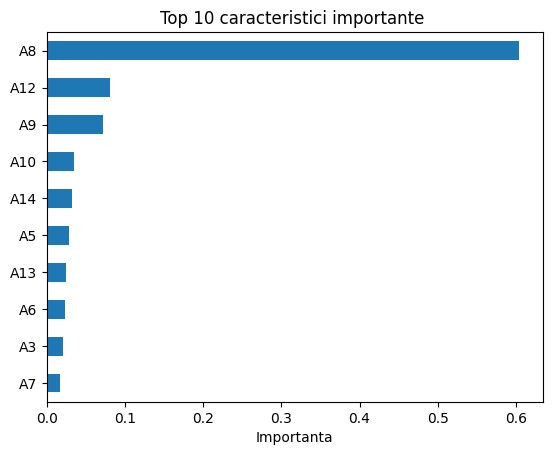

In [17]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score


def calc_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }

#hiperparametrii
max_depth_values = [3, 6, 10]
n_estimators_values = [50, 100, 200]
learning_rate_values = [0.01, 0.1, 0.3]

results = []
best_model = None
best_params = None
best_f1 = -1.0
id = 0

for max_depth in max_depth_values:
    for n_estimators in n_estimators_values:
        for learning_rate in learning_rate_values:
            id += 1

            params = {
                'max_depth': max_depth,
                'n_estimators': n_estimators,
                'learning_rate': learning_rate,
            }

            model = XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=42,
                n_jobs=-1,
                **params,
            )
            model.fit(x_train, y_train)

            y_pred = model.predict(x_test)
            metrics = calc_metrics(y_test, y_pred)

            row = {
                'id': id,
                'max_depth': max_depth,
                'n_estimators': n_estimators,
                'learning_rate': learning_rate,
                'accuracy': metrics['accuracy'],
                'f1': metrics['f1'],
            }
            results.append(row)

            if metrics['f1'] > best_f1:
                best_f1 = metrics['f1']
                best_model = model
                best_params = params

results_df = pd.DataFrame(results).sort_values(by='f1', ascending=False)

print('Rezultate (sortate dupa F1):')
print(results_df)
print('\n')

print('Cei mai buni hiperparametri:')
print(best_params)

best_metrics = results_df.iloc[0]
print('\nCele mai bune metrici:')
print(f"accuracy: {best_metrics['accuracy']}")
print(f"f1: {best_metrics['f1']}")

# Importanta caracteristicilor pentru modelul cel mai bun
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importanta': best_model.feature_importances_,
}).sort_values(by='Importanta', ascending=False)

print('\nTop 10 caracteristici importante:')
print(feature_importance.head(10))
feature_importance=feature_importance.head(10).sort_values(by='Importanta', ascending=True)
feature_importance.head(10).plot(
    kind='barh',
    x='Feature',
    y='Importanta',
    legend=False,
)
plt.title('Top 10 caracteristici importante ')
plt.xlabel('Importanta')
plt.ylabel('')
plt.show()


### Interpretarea rezultatelor

Am folosit doar doua metrici:
- `accuracy` - procentul total de predictii corecte;
- `F1-score` - echilibru intre precision si recall.

Am rulat toate combinatiile din grid pentru `max_depth`, `n_estimators` si `learning_rate`, apoi am ales modelul cu F1 maxim.

